# Деревья решений и ансамбли. Вариант 12

Нужно восстановить путь объекта от корня до листа и объяснить ответ дерева.

Данные — `make_classification` из примера «Случайный лес.ipynb»: 2 000 объектов, два числовых признака, два класса, `class_sep=2`, `flip_y=0.2`, seed 17. Координаты синтетические, без физических единиц. Долю test фиксируем на 25%, на остальных данных используем пятиблочную стратифицированную CV. Seed разбиения и моделей — 42, CV — 2026. Baseline — предсказание частого класса; метрики — macro-F1 и accuracy.

Гипотеза: на шумных данных короткое дерево обобщает лучше глубокого, а его решение можно объяснить несколькими проверками.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

Path('results').mkdir(exist_ok=True)
Path('figures').mkdir(exist_ok=True)
SEED = 42

def scores(y, pred):
    return {'f1': float(f1_score(y, pred, average='macro')),
            'accuracy': float(accuracy_score(y, pred))}

def savefig(name):
    plt.tight_layout()
    plt.savefig('figures/' + name, dpi=140, bbox_inches='tight')
    plt.show()

## Данные

Сначала повторим базовый пример из «Деревья решений.ipynb»: обучение CART на Iris. Это проверка на обучающей выборке, а не оценка обобщения.

In [2]:
iris = load_iris()
example = DecisionTreeClassifier(random_state=SEED).fit(iris.data, iris.target)
print('Iris, train accuracy:', example.score(iris.data, iris.target))

Iris, train accuracy: 1.0


In [3]:
X, y = make_classification(n_samples=2000, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, class_sep=2, flip_y=0.2, random_state=17)
X = X.astype(np.float32)
train_ids, test_ids = train_test_split(np.arange(len(y)), test_size=0.25,
                                     stratify=y, random_state=SEED)
Xtr, Xte, ytr, yte = X[train_ids], X[test_ids], y[train_ids], y[test_ids]
assert np.isfinite(X).all() and len(np.unique(X, axis=0)) == len(X)
assert set(train_ids).isdisjoint(test_ids)
cv = list(StratifiedKFold(5, shuffle=True, random_state=2026).split(Xtr, ytr))
data = pd.DataFrame(X, columns=['x1', 'x2'])
data['target'] = y
data['split'] = np.where(np.isin(np.arange(len(y)), test_ids), 'test', 'train')
data.to_csv('results/data.csv', index_label='id')
print('Train:', Xtr.shape, 'test:', Xte.shape, '; пропусков и дубликатов нет.')
display(pd.crosstab(data['split'], data['target']))

Train: (1500, 2) test: (500, 2) ; пропусков и дубликатов нет.


target,0,1
split,,
test,246,254
train,737,763


## Эксперименты

| № | Изменение | Фиксированные условия |
|---|---|---|
| 1 | Глубина: 1, 3, без ограничения | Gini, минимальный лист 1 |
| 2 | Минимальный лист: 1 или 20 | Глубина 3, Gini |
| 3 | Дерево, bagging, random forest | Глубина 3, лист 1; в ансамблях 100 деревьев |

Во всех сравнениях одинаковые folds и seed. Дополнительно сравним AdaBoost и GradientBoosting и проверим stacking. Для него базовые прогнозы метамодели получаются по внутренней трёхблочной OOF-схеме; масштабирование находится внутри pipeline. Всего 10 конфигураций по 5 запусков. Дерево глубины 3 используем для разбора путей; лучший вариант по качеству определяем по среднему CV F1.

In [4]:
def tree(depth, leaf=1):
    return DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf, random_state=SEED)

models = {
    'dummy': DummyClassifier(strategy='most_frequent'),
    'tree_1': tree(1), 'tree_3': tree(3), 'tree_full': tree(None),
    'tree_3_leaf20': tree(3, 20),
    'bagging': BaggingClassifier(estimator=tree(3), n_estimators=100, random_state=SEED),
    'forest': RandomForestClassifier(max_depth=3, max_features=1, n_estimators=100, random_state=SEED),
    'adaboost': AdaBoostClassifier(estimator=tree(1), n_estimators=100, learning_rate=0.1, random_state=SEED),
    'gradient': GradientBoostingClassifier(max_depth=2, n_estimators=100, learning_rate=0.1, random_state=SEED),
    'stacking': StackingClassifier(estimators=[
        ('lr', make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
        ('tree', tree(3)),
        ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(15)))],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=StratifiedKFold(3, shuffle=True, random_state=SEED))
}
results, rows = {}, []
for name, model in models.items():
    results[name] = {'parameters': model.get_params(), 'train_metric': [],
                     'validation_metric': [], 'final_metric': None}
    for fold, (tr, va) in enumerate(cv):
        m = clone(model).fit(Xtr[tr], ytr[tr])
        train_score = scores(ytr[tr], m.predict(Xtr[tr]))
        val_score = scores(ytr[va], m.predict(Xtr[va]))
        results[name]['train_metric'].append(train_score)
        results[name]['validation_metric'].append(val_score)
        rows.append({'model': name, 'fold': fold, 'train_f1': train_score['f1'],
                     'cv_f1': val_score['f1'], 'cv_accuracy': val_score['accuracy']})
runs = pd.DataFrame(rows)
runs.to_csv('results/cv_runs.csv', index=False)
summary = runs.groupby('model', sort=False).agg(train_f1=('train_f1', 'mean'),
    cv_f1=('cv_f1', 'mean'), cv_sd=('cv_f1', 'std'), cv_accuracy=('cv_accuracy', 'mean'))
best = summary.cv_f1.idxmax()
print('Максимальный средний CV F1:', best)
display(summary.round(4))

Максимальный средний CV F1: tree_1


,train_f1,cv_f1,cv_sd,cv_accuracy
model,,,,
dummy,0.3372,0.3372,0.0008,0.5087
tree_1,0.8953,0.8953,0.0154,0.8953
tree_3,0.8973,0.8913,0.0117,0.8913
tree_full,1.0000,0.8178,0.0285,0.8180
tree_3_leaf20,0.8953,0.8953,0.0154,0.8953
bagging,0.8962,0.8947,0.0156,0.8947
forest,0.8955,0.8940,0.0161,0.8940
adaboost,0.8953,0.8953,0.0154,0.8953
gradient,0.9015,0.8927,0.0150,0.8927


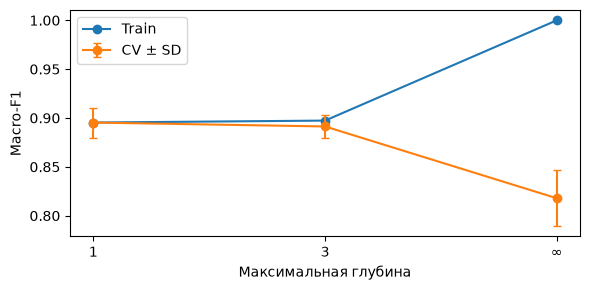

In [5]:
depths = summary.loc[['tree_1', 'tree_3', 'tree_full']]
plt.figure(figsize=(6, 3))
plt.plot(['1', '3', '∞'], depths.train_f1, 'o-', label='Train')
plt.errorbar(['1', '3', '∞'], depths.cv_f1, yerr=depths.cv_sd, fmt='o-', capsize=3, label='CV ± SD')
plt.xlabel('Максимальная глубина')
plt.ylabel('Macro-F1')
plt.legend()
savefig('depth.png')

1. При росте глубины с 1 до неограниченной train F1 достигает 1, а CV F1 падает с 0,8953 до 0,8178: дерево переобучается.
2. При глубине 3 увеличение минимального листа с 1 до 20 поднимает CV F1 с 0,8913 до 0,8953.
3. Bagging и лес дают CV F1 0,8947 и 0,8940 против 0,8913 у одиночного дерева глубины 3. Разница меньше разброса по folds.

AdaBoost и GradientBoosting получили CV F1 0,8953 и 0,8927. Stacking также даёт около 0,8953. По accuracy вывод тот же: усложнение модели почти не помогает.

## OOF и отложенная выборка

Проверим OOF отдельно на дереве: каждый объект обучающей части получит прогноз модели, которая его не видела. F1 по всем OOF-прогнозам может немного отличаться от среднего F1 по folds. Затем оценим фиксированные конфигурации на test; параметры по этим результатам не меняем.

In [6]:
oof = cross_val_predict(models['tree_3'], Xtr, ytr, cv=cv)
pd.DataFrame({'id': train_ids, 'actual': ytr, 'oof_pred': oof}).to_csv('results/oof.csv', index=False)
print('OOF дерева:', scores(ytr, oof))
fitted, predictions = {}, {}
for name, model in models.items():
    fitted[name] = clone(model).fit(Xtr, ytr)
    predictions[name] = fitted[name].predict(Xte)
    results[name]['final_metric'] = scores(yte, predictions[name])
    summary.loc[name, 'test_f1'] = results[name]['final_metric']['f1']
    summary.loc[name, 'test_accuracy'] = results[name]['final_metric']['accuracy']
summary.to_csv('results/experiments.csv')
Path('results/experiments.json').write_text(json.dumps(results, default=str, indent=2), encoding='utf-8')
display(summary[['cv_f1', 'cv_sd', 'test_f1', 'test_accuracy']].round(4))

OOF дерева: {'f1': 0.8913321259125102, 'accuracy': 0.8913333333333333}


,cv_f1,cv_sd,test_f1,test_accuracy
model,,,,
dummy,0.3372,0.0008,0.3369,0.508
tree_1,0.8953,0.0154,0.8840,0.884
tree_3,0.8913,0.0117,0.8800,0.880
tree_full,0.8178,0.0285,0.7800,0.780
tree_3_leaf20,0.8953,0.0154,0.8840,0.884
bagging,0.8947,0.0156,0.8840,0.884
forest,0.8940,0.0161,0.8860,0.886
adaboost,0.8953,0.0154,0.8840,0.884
gradient,0.8927,0.0150,0.8780,0.878


На test дерево глубины 3 получило accuracy 0,880 против 0,508 у baseline. У короткого дерева и большинства ансамблей accuracy около 0,884. Максимум у леса — 0,886; разница с деревом глубины 1 составляет один объект из 500.

## Вариант 12: пути и ошибки

Покажем дерево глубины 3 и его разбиения. В каждом узле условие `x[j] <= threshold` ведёт влево, иначе вправо. Класс в листе определяется большинством обучающих объектов.

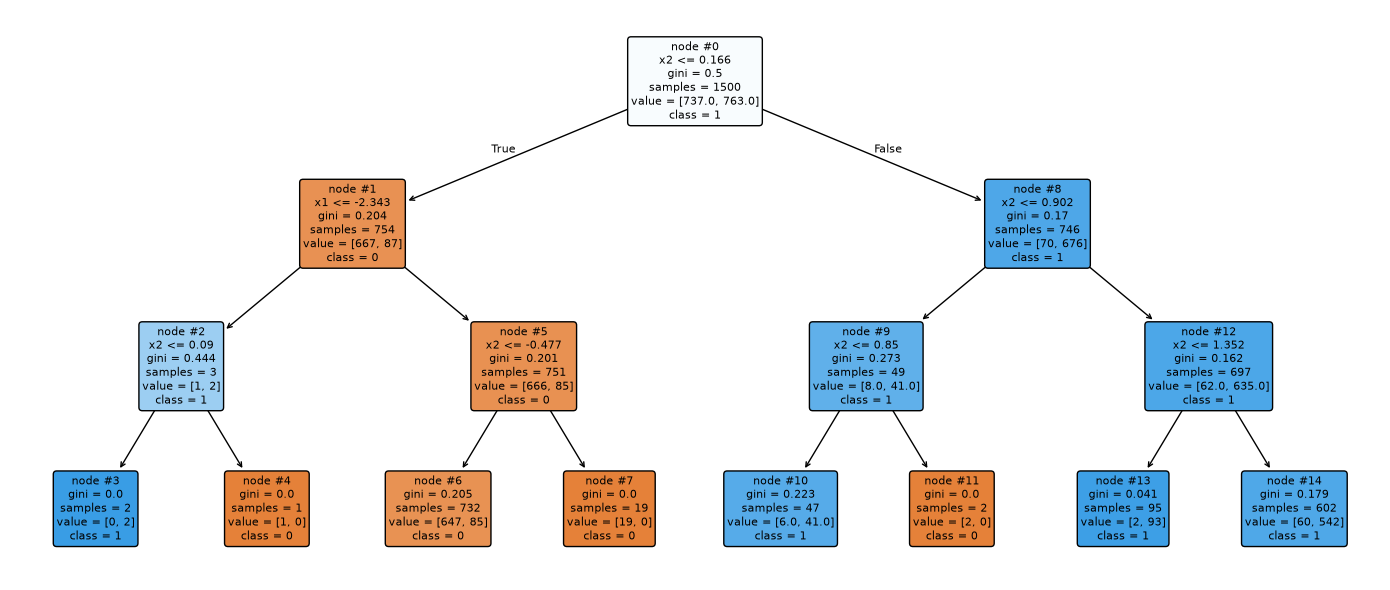

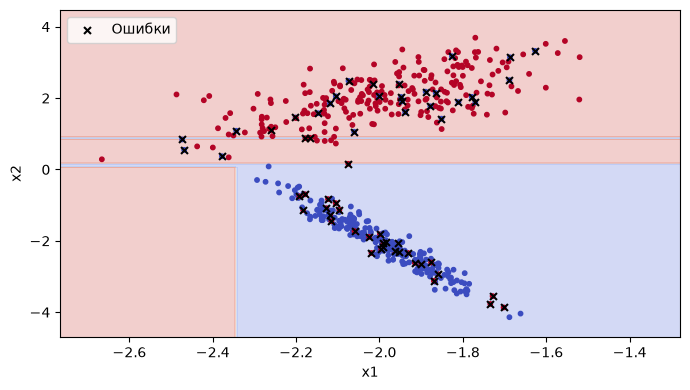

In [7]:
model = fitted['tree_3']
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(model, feature_names=['x1', 'x2'], class_names=['0', '1'],
          node_ids=True, filled=True, rounded=True, fontsize=8, ax=ax)
savefig('tree.png')

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-.1, X[:,0].max()+.1, 200),
                     np.linspace(X[:,1].min()-.1, X[:,1].max()+.1, 200))
z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
errors = predictions['tree_3'] != yte
plt.figure(figsize=(7, 4))
plt.contourf(xx, yy, z, alpha=.25, cmap='coolwarm')
plt.scatter(Xte[:,0], Xte[:,1], c=yte, cmap='coolwarm', s=10)
plt.scatter(Xte[errors,0], Xte[errors,1], marker='x', color='black', s=25, label='Ошибки')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
savefig('regions.png')

In [8]:
def explain(x):
    t, node, nodes, conditions = model.tree_, 0, [0], []
    while t.children_left[node] != t.children_right[node]:
        j, threshold = t.feature[node], t.threshold[node]
        left = x[j] <= threshold
        conditions.append(f'x{j+1}={x[j]:.4f} {"≤" if left else ">"} {threshold:.4f}')
        node = int(t.children_left[node] if left else t.children_right[node])
        nodes.append(node)
    assert nodes == model.decision_path(x.reshape(1, -1)).indices.tolist()
    counts = np.bincount(ytr[model.apply(Xtr) == node], minlength=2)
    assert counts.argmax() == model.predict(x.reshape(1, -1))[0]
    return ' → '.join(map(str, nodes)), '; '.join(conditions), counts.tolist()

# Пять ошибок и один верный ответ; порядок выбора — по исходному ID.
wrong = sorted(np.flatnonzero(errors), key=lambda i: test_ids[i])[:5]
correct = sorted(np.flatnonzero(~errors), key=lambda i: test_ids[i])[:1]
paths = []
for i in wrong + correct:
    route, conditions, counts = explain(Xte[i])
    paths.append({'id': int(test_ids[i]), 'path': route, 'conditions': conditions,
                  'leaf_counts_0_1': counts, 'actual': int(yte[i]),
                  'tree': int(predictions['tree_3'][i]), 'forest': int(predictions['forest'][i]),
                  'gradient': int(predictions['gradient'][i])})
paths = pd.DataFrame(paths)
paths.to_csv('results/paths.csv', index=False)
with pd.option_context('display.max_colwidth', None):
    display(paths)

,id,path,conditions,leaf_counts_0_1,actual,tree,forest,gradient
0,28,0 → 8 → 12 → 13,x2=1.0843 > 0.1664; x2=1.0843 > 0.9025; x2=1.0843 ≤ 1.3523,"[2, 93]",0,1,1,1
1,52,0 → 1 → 5 → 6,x2=-2.9290 ≤ 0.1664; x1=-1.8606 > -2.3425; x2=-2.9290 ≤ -0.4772,"[647, 85]",1,0,0,0
2,69,0 → 8 → 12 → 14,x2=2.5013 > 0.1664; x2=2.5013 > 0.9025; x2=2.5013 > 1.3523,"[60, 542]",0,1,1,1
3,86,0 → 8 → 12 → 13,x2=1.1168 > 0.1664; x2=1.1168 > 0.9025; x2=1.1168 ≤ 1.3523,"[2, 93]",0,1,1,1
4,193,0 → 8 → 12 → 14,x2=1.5760 > 0.1664; x2=1.5760 > 0.9025; x2=1.5760 > 1.3523,"[60, 542]",0,1,1,1
5,1,0 → 8 → 12 → 14,x2=1.7858 > 0.1664; x2=1.7858 > 0.9025; x2=1.7858 > 1.3523,"[60, 542]",1,1,1,1


В столбце `leaf_counts_0_1` указано число обучающих объектов каждого класса в листе. Например, объект 28 проходит узлы 0 → 8 → 12 → 13: его x2 больше первых двух порогов, но меньше третьего. В листе 93 объекта класса 1 и только 2 класса 0, поэтому ответ — 1, хотя метка объекта — 0.

Объект 86 попал в тот же лист и ошибочно получил тот же класс. Для 69 и 193 дерево выбрало класс 1 по большинству 542 против 60. У объекта 52 обратная ситуация: метка 1, но в листе преобладает класс 0 — 647 против 85. Лес и boosting на всех пяти объектах тоже ошиблись. Объект 1 приведён для сравнения: большинство в его листе совпало с меткой.

Возможные причины ошибок — шум меток и перекрытие классов. Установить причину для конкретного объекта по пути нельзя. `flip_y=0.2` означает случайное переназначение части меток; новая метка может совпасть со старой.

## Важность признаков

Сравним важности по уменьшению impurity у дерева и леса. Они описывают использование признаков моделью, а не причинность.

In [9]:
importance = pd.DataFrame({'tree': model.feature_importances_,
                           'forest': fitted['forest'].feature_importances_}, index=['x1', 'x2'])
importance.to_csv('results/importance.csv')
display(importance.round(4))

,tree,forest
x1,0.0038,0.111
x2,0.9962,0.889


У дерева почти вся важность приходится на x2: 0,996. Это видно и по разбиениям. Лес чаще использует x1 из-за случайного выбора признака, но x2 остаётся главным (0,889).

## Контрольные вопросы

> Почему bagging снижает variance?

Bagging снижает разброс за счёт усреднения разных деревьев. Чем сильнее коррелируют ошибки, тем меньше выигрыш.

> Чем boosting отличается от bagging по порядку обучения?

В bagging модели обучаются независимо; в boosting каждая следующая модель исправляет ошибки текущего ансамбля.

> Почему stacking требует out-of-fold предсказаний?

Без OOF метамодель учится на слишком оптимистичных прогнозах базовых моделей для их же обучающих объектов.

> Может ли важность признака быть ложной из-за корреляции?

Да: коррелирующие признаки могут заменять друг друга, поэтому важность распределяется между ними нестабильно.

> Как глубина дерева связана с переобучением?

Большая глубина позволяет запоминать шумные метки: train-качество растёт, а качество на новых данных может падать.

## Вывод

Гипотеза подтвердилась на этом наборе: дерево глубины 1 дало CV F1 0,8953, полное дерево — 0,8178. Глубины 3 достаточно, чтобы показать решение тремя проверками и восстановить его для каждого разобранного объекта. Прозрачность пути не гарантирует правильность ответа: в пяти ошибках метка объекта не совпала с большинством в листе.

Ансамбли дали близкое качество и не исправили разобранные ошибки. Вывод ограничен синтетическими данными и одним разбиением. Для дальнейшей проверки стоит повторить эксперимент на нескольких разбиениях и на реальных данных.